In [91]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle

from scipy.signal import detrend

In [92]:
#Data Upload

VVV_data = fits.open('VVV_Sample.fits')

Id_b278, Id_b279 = VVV_data[1].data,VVV_data[11].data

Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data

#Removing np.nan 

# Remove missing values (NaNs) from all Ks-related data arrays

def remove_nans(array2d):
    return [row[~np.isnan(row)] for row in array2d]

def _safe_norm(x):
    xmin, xmax = np.min(x), np.max(x)
    return (x - xmin) / (xmax - xmin)

Ks_b278 = remove_nans(Ks_b278)
Ks_b279 = remove_nans(Ks_b279)

Ks_err_b278 = remove_nans(Ks_err_b278)
Ks_err_b279 = remove_nans(Ks_err_b279)

Ks_mjd_b278 = remove_nans(Ks_mjd_b278)
Ks_mjd_b279 = remove_nans(Ks_mjd_b279)

In [93]:
VVV_data.info()

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [135]:
i = 303 # estrella que quieres analizar

t = Ks_mjd_b278[i]
y = Ks_b278[i]
dy = Ks_err_b278[i]
Star = Id_b278[i]

mask = dy < np.percentile(dy, 90)
t, y, dy = t[mask], y[mask], dy[mask]
y = detrend(y)

ls = LombScargle(t, y)
frequency, power = ls.autopower()

best_frequency = frequency[np.argmax(power)]
period = 1 / best_frequency

false_alarm_prob = ls.false_alarm_probability(np.max(power))

print("Estrella: ", Star, "    Periodo:", period, "   False alarm probability: ", false_alarm_prob)

Estrella:  13685776000901     Periodo: 131.19888236062178    False alarm probability:  0.054636118810562316


In [136]:
print("min freq:", np.min(frequency))
print("max freq:", np.max(frequency))
print("min period:", 1/np.max(frequency))
print("max period:", 1/np.min(frequency))

min freq: 3.949231164955567e-05
max freq: 0.0839211622553058
min period: 11.91594555087059
max period: 25321.384295600004


In [137]:
print("N puntos:", len(t))
print("Span temporal:", np.max(t) - np.min(t))
print("Periodo:", period)

N puntos: 85
Span temporal: 2532.13842956
Periodo: 131.19888236062178


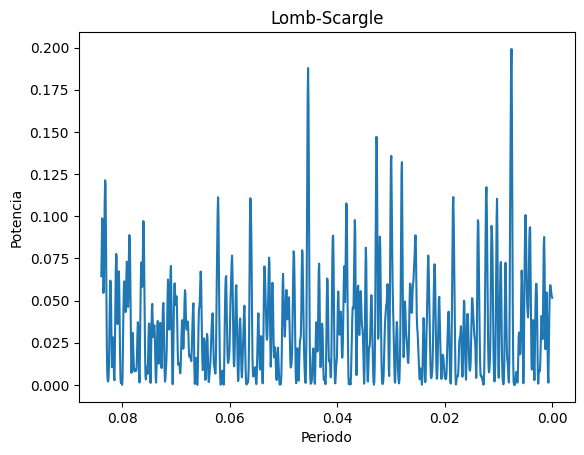

In [138]:
plt.plot(frequency, power)
plt.xlabel("Periodo")
plt.ylabel("Potencia")
plt.title("Lomb-Scargle")
plt.gca().invert_xaxis()  # opcional (astro style)
plt.show()

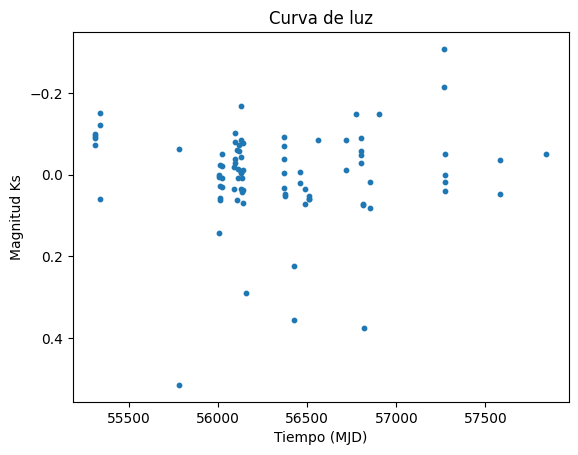

In [139]:
plt.figure()
plt.scatter(t, y, s=10)
plt.xlabel("Tiempo (MJD)")
plt.ylabel("Magnitud Ks")
plt.title("Curva de luz")
plt.gca().invert_yaxis()  # estándar en astronomía
plt.show()

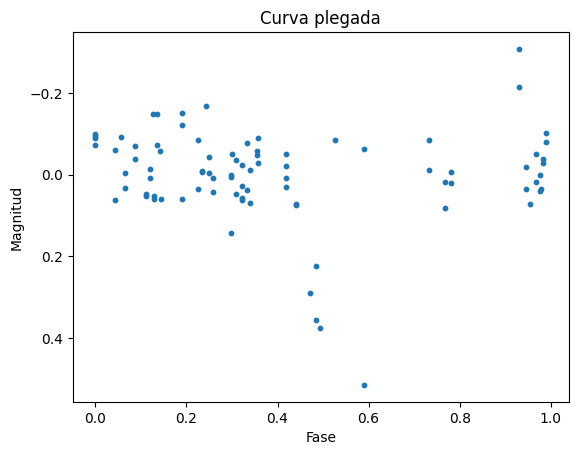

In [140]:
t0 = t[0]  # o mejor: el tiempo del máximo brillo
phase = ((t - t0) / period) % 1

plt.scatter(phase, y, s=10)
plt.xlabel("Fase")
plt.ylabel("Magnitud")
plt.title("Curva plegada")
plt.gca().invert_yaxis()

Text(0.5, 1.0, 'Periodo = 131.199')

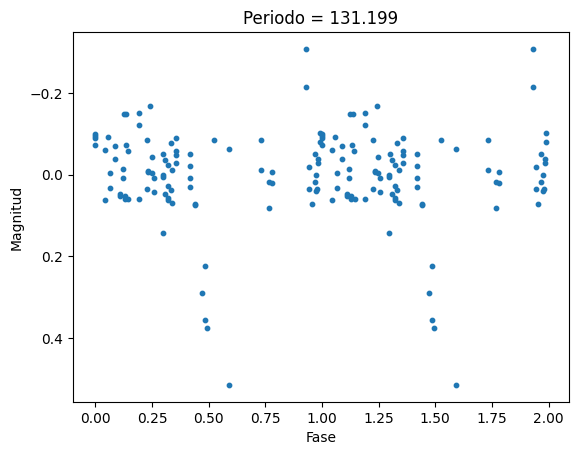

In [141]:
phase2 = np.concatenate([phase, phase + 1])
y2 = np.concatenate([y, y])

plt.scatter(phase2, y2, s=10)
plt.gca().invert_yaxis()
plt.xlabel("Fase")
plt.ylabel("Magnitud")
plt.title(f"Periodo = {period:.3f}")